# Modeling U.S. Credit Response to Rising Interest Rates 

## Step 1: Imports & Environment Setup

### Imports

In [15]:
import os
import sys
from pathlib import Path
from typing import Dict, Any

import yaml
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fredapi import Fred
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

### Verfiy Assets

In [16]:
logger = logging.getLogger("consumer-credit-analysis")

SECRETS_PATH = "../secrets.yaml"

if Path(SECRETS_PATH).exists():
        logger.info("secrets.yaml is properly configured.")
else:
    logger.info('secrets.yaml is not properly configured. Create a secrets.yaml file and add in your FRED API Key. i.e. `FRED_API_KEY:"XXXXXXXXXXXXXXXXXXXXXXX"`')


### Load Secrets File

In [17]:
def _load_yaml_file(path: str, name: str) -> Dict[str, Any]:
    """
    Helper to load any YAML file with a consistent error message.
    """
    abs_path = os.path.abspath(path)
    if not os.path.exists(abs_path):
        raise FileNotFoundError(f"{name} file not found at: {abs_path}")
    with open(abs_path, "r") as f:
        return yaml.safe_load(f) or {}

def load_secrets(secrets_path: str = "secrets.yaml") -> Dict[str, Any]:
    """
    Load application secrets from a YAML file.
    Args:
        secrets_path: Path to the secrets YAML file.

    Returns:
        Secrets dict.

    Raises:
        FileNotFoundError: If the secrets file is not found.
    """
    # If using an external secrets manager, you can create
    # an (empty) secrets.yaml stub in this path to satisfy the loader.
    return _load_yaml_file(secrets_path, "secrets.yaml")

secrets = load_secrets(SECRETS_PATH)
logger.info("Secrets Loaded")

### Setup FRED API Key

In [18]:
api_key = secrets.get("FRED_API_KEY")
fred = Fred(api_key=api_key)
logger.info("FRED API Key Successfully Setup.")

## Step 2: Data Download + Cleaning

In [19]:
# Download data
credit = fred.get_series('TOTALSL')
revolving = fred.get_series('REVOLSL')
nonrev = fred.get_series('NONREVSL')
fedfunds = fred.get_series('FEDFUNDS')

# Combine
df = pd.DataFrame({
    'credit_total': credit,
    'revolving': revolving,
    'nonrevolving': nonrev,
    'fedfunds': fedfunds
})

df = df.dropna()
logger.info("Datasets loaded and cleaned.")

## Step 3: Exploratory Data Analysis (EDA)

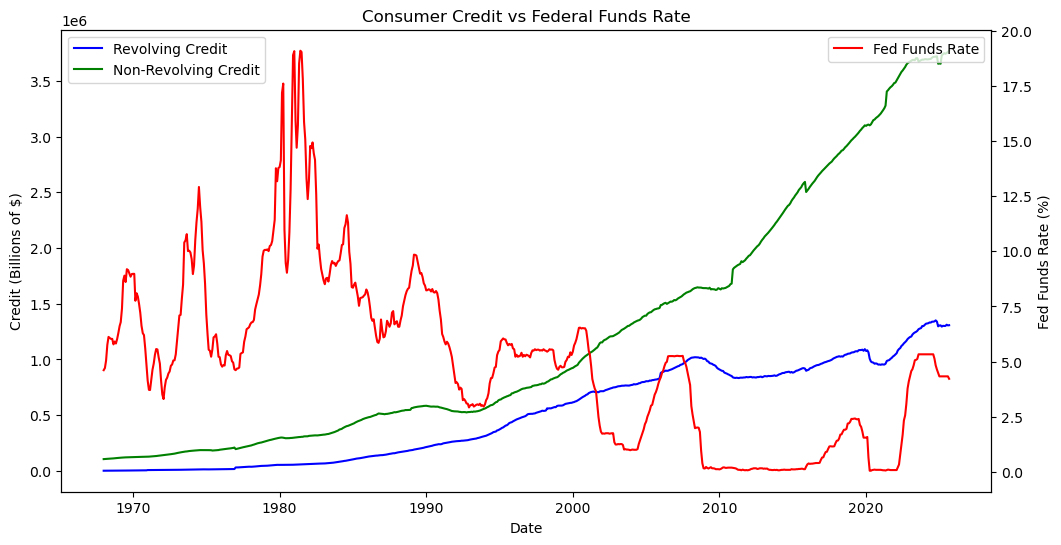

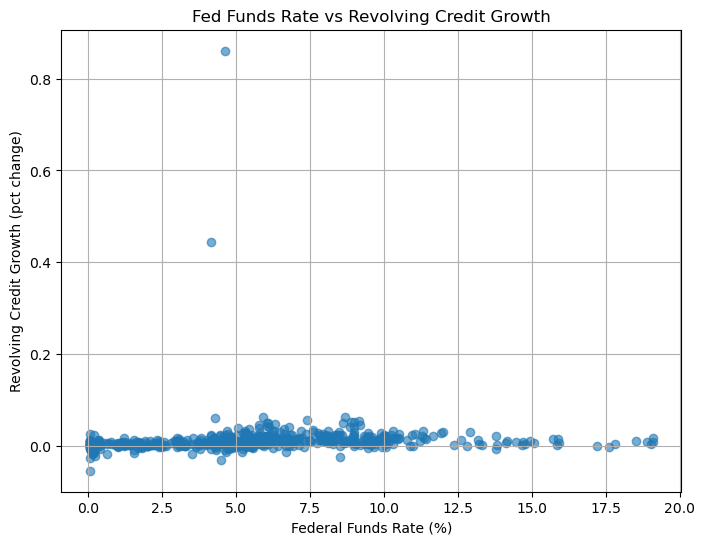

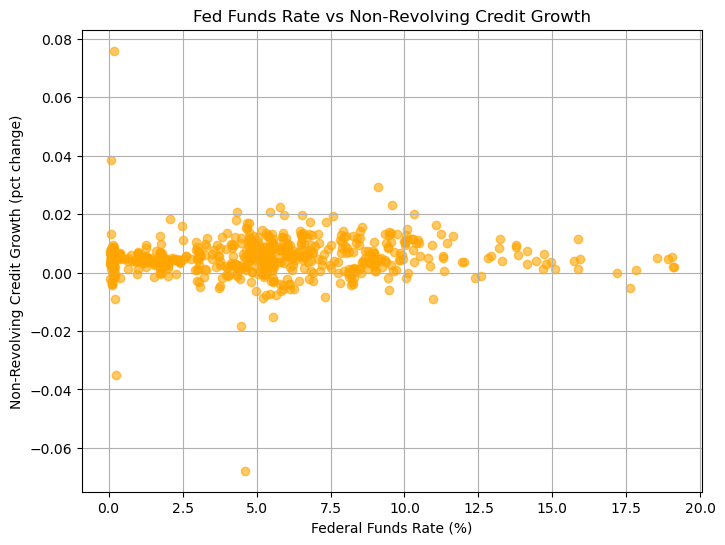

In [20]:
# --- Growth rate calculations ---
df['revolving_growth'] = df['revolving'].pct_change()
df['nonrev_growth'] = df['nonrevolving'].pct_change()

# ---------------------------------------------------------------
# TIME-SERIES PLOT with dual y-axes (so fed funds is visible)
# ---------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot credit levels
ax1.plot(df.index, df['revolving'], label='Revolving Credit', color='blue')
ax1.plot(df.index, df['nonrevolving'], label='Non-Revolving Credit', color='green')
ax1.set_xlabel("Date")
ax1.set_ylabel("Credit (Billions of $)")
ax1.legend(loc="upper left")

# Second axis for Fed Funds Rate
ax2 = ax1.twinx()
ax2.plot(df.index, df['fedfunds'], label='Fed Funds Rate', color='red')
ax2.set_ylabel("Fed Funds Rate (%)")
ax2.legend(loc="upper right")

plt.title("Consumer Credit vs Federal Funds Rate")
plt.show()

# ---------------------------------------------------------------
# SCATTER PLOTS (Cleaned for NaNs)
# ---------------------------------------------------------------
df_scatter = df[['fedfunds', 'revolving_growth', 'nonrev_growth']].dropna()

# Revolving credit growth vs interest rate
plt.figure(figsize=(8,6))
plt.scatter(df_scatter['fedfunds'], df_scatter['revolving_growth'], alpha=0.6)
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Revolving Credit Growth (pct change)")
plt.title("Fed Funds Rate vs Revolving Credit Growth")
plt.grid(True)
plt.show()

# Non-revolving credit growth vs interest rate
plt.figure(figsize=(8,6))
plt.scatter(df_scatter['fedfunds'], df_scatter['nonrev_growth'], alpha=0.6, color='orange')
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("Non-Revolving Credit Growth (pct change)")
plt.title("Fed Funds Rate vs Non-Revolving Credit Growth")
plt.grid(True)
plt.show()


## Step 4: Modeling

### Model 1: Linear Regression for revolving credit growth (12month)
Question: Do higher interest rates reduce revolving credit growth?

In [21]:
df["revolving_growth_12m"] = df["revolving"].pct_change(12)
df["nonrev_growth_12m"] = df["nonrevolving"].pct_change(12)

# Lagged Fed Funds rate: consumers respond with delay
for lag in [0, 3, 6, 12]:
    df[f"fedfunds_lag{lag}"] = df["fedfunds"].shift(lag)

# Drop rows with missing values created by pct_change / shift
df_model = df[[
    "revolving_growth_12m",
    "nonrev_growth_12m",
    "fedfunds_lag0",
    "fedfunds_lag3",
    "fedfunds_lag6",
    "fedfunds_lag12"
]].dropna()

print("Model dataframe shape:", df_model.shape)
display(df_model.head())

Model dataframe shape: (681, 6)


,revolving_growth_12m,nonrev_growth_12m,fedfunds_lag0,fedfunds_lag3,fedfunds_lag6,fedfunds_lag12
1969-01-01,0.623298,0.100828,6.30,5.91,6.03,4.61
1969-02-01,0.631125,0.100057,6.61,5.82,6.03,4.71
1969-03-01,0.633481,0.101117,6.79,6.02,5.78,5.05
1969-04-01,0.650292,0.101417,7.41,6.30,5.91,5.76
1969-05-01,0.685944,0.102285,8.67,6.61,5.82,6.12


In [ ]:

features_m1 = ["fedfunds_lag0", "fedfunds_lag3", "fedfunds_lag6", "fedfunds_lag12"]
target_m1 = "revolving_growth_12m"

X1 = df_model[features_m1]
y1 = df_model[target_m1]

# keep time order (no shuffle) so it's more like train on past, test on future
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, shuffle=False
)

model1_ext = LinearRegression().fit(X1_train, y1_train)
y1_pred = model1_ext.predict(X1_test)

r2_1 = r2_score(y1_test, y1_pred)
rmse_1 = np.sqrt(mean_squared_error(y1_test, y1_pred))

print("=== Model 1 - Linear Regression (Revolving 12m Growth) ===")
print("Coefficients:")
for name, coef in zip(features_m1, model1_ext.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {model1_ext.intercept_:.4f}")
print(f"R^2 (test): {r2_1:.3f}")
print(f"RMSE (test): {rmse_1:.4f}")


=== Model 1 – Linear Regression (Revolving 12m Growth) ===
Coefficients:
  fedfunds_lag0: 0.0141
  fedfunds_lag3: 0.0011
  fedfunds_lag6: -0.0015
  fedfunds_lag12: 0.0005
Intercept: 0.0831
R^2 (test): -1.135
RMSE (test): 0.0904


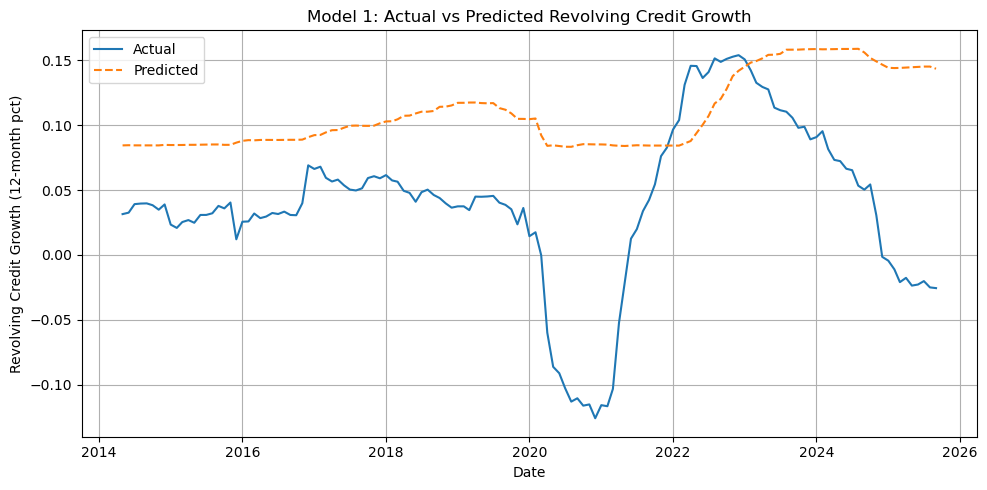

In [23]:
plt.figure(figsize=(10,5))
plt.plot(y1_test.index, y1_test, label="Actual", linewidth=1.5)
plt.plot(y1_test.index, y1_pred, label="Predicted", linestyle="--", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Revolving Credit Growth (12-month pct)")
plt.title("Model 1: Actual vs Predicted Revolving Credit Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Model 2: Random Forest for non-revolving credit growth
Question: Is non-revolving credit less sensitive to rate changes?

=== Model 2 – Random Forest (Non-Revolving 12m Growth) ===
R^2 (test): -1.569
RMSE (test): 0.0426

Feature importances:


fedfunds_lag12    0.424232
fedfunds_lag0     0.340798
fedfunds_lag6     0.126926
fedfunds_lag3     0.108043
dtype: float64

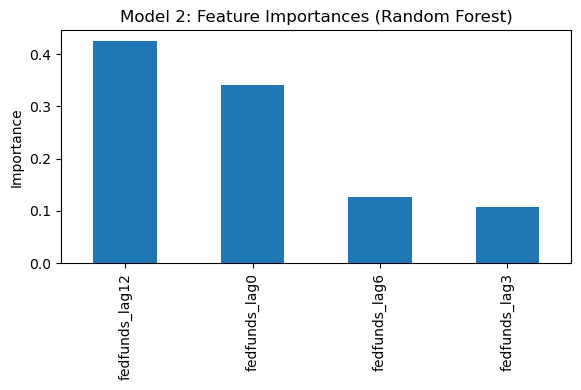

In [ ]:
# -------------------------------------------------------------------
# 3) Model 2 – Random Forest: Non-revolving 12m growth
# -------------------------------------------------------------------

features_m2 = ["fedfunds_lag0", "fedfunds_lag3", "fedfunds_lag6", "fedfunds_lag12"]
target_m2 = "nonrev_growth_12m"

X2_ext = df_model[features_m2]
y2_ext = df_model[target_m2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_ext, y2_ext, test_size=0.2, shuffle=False
)

model2_ext = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
).fit(X2_train, y2_train)

y2_pred = model2_ext.predict(X2_test)

r2_2 = r2_score(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print("=== Model 2 - Random Forest (Non-Revolving 12m Growth) ===")
print(f"R^2 (test): {r2_2:.3f}")
print(f"RMSE (test): {rmse_2:.4f}")

# Feature importances (great bar chart for the slide)
importances = pd.Series(
    model2_ext.feature_importances_,
    index=features_m2
).sort_values(ascending=False)

print("\nFeature importances:")
display(importances)

plt.figure(figsize=(6,4))
importances.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Model 2: Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


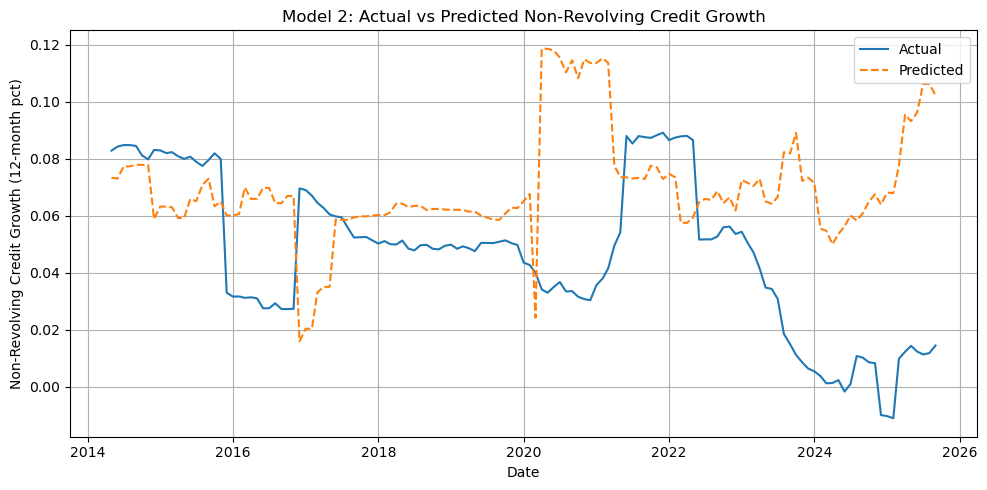

In [25]:
plt.figure(figsize=(10,5))
plt.plot(y2_test.index, y2_test, label="Actual", linewidth=1.5)
plt.plot(y2_test.index, y2_pred, label="Predicted", linestyle="--", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Non-Revolving Credit Growth (12-month pct)")
plt.title("Model 2: Actual vs Predicted Non-Revolving Credit Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()